# SHAP Computational Complexity Demonstration

This notebook demonstrates:

1. Why exact Shapley values are exponential
2. How sampling reduces complexity
3. Why TreeSHAP is dramatically faster

In [10]:
import itertools
import numpy as np
import time
import math
import matplotlib.pyplot as plt

# For TreeSHAP demo
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

## Exact Shapley Value Computation

Shapley requires evaluating **all subsets** of features.

Number of subsets:  
$2^n$

Overall complexity:
$O(n 2^n)$

We now implement the brute-force version.

In [11]:
def model(x):
    # Simple nonlinear function with interactions
    return np.sum(x) + 0.5 * np.prod(x)

def shapley_exact(model, x):
    n = len(x)
    shapley_values = np.zeros(n)
    features = list(range(n))

    for i in features:
        others = [j for j in features if j != i]

        for r in range(len(others) + 1):
            for subset in itertools.combinations(others, r):

                subset = list(subset)

                x_subset = np.zeros(n)
                x_subset[subset] = x[subset]

                x_subset_with_i = x_subset.copy()
                x_subset_with_i[i] = x[i]

                marginal = model(x_subset_with_i) - model(x_subset)

                weight = (
                    math.factorial(len(subset)) *
                    math.factorial(n - len(subset) - 1) /
                    math.factorial(n)
                )

                shapley_values[i] += weight * marginal

    return shapley_values

## Measuring Runtime Growth

Observe how runtime increases with number of features.

Features: 4, Time: 0.0013 sec
Features: 5, Time: 0.0024 sec
Features: 6, Time: 0.0041 sec
Features: 7, Time: 0.0103 sec
Features: 8, Time: 0.0294 sec
Features: 9, Time: 0.0459 sec
Features: 10, Time: 0.0977 sec
Features: 11, Time: 0.2176 sec


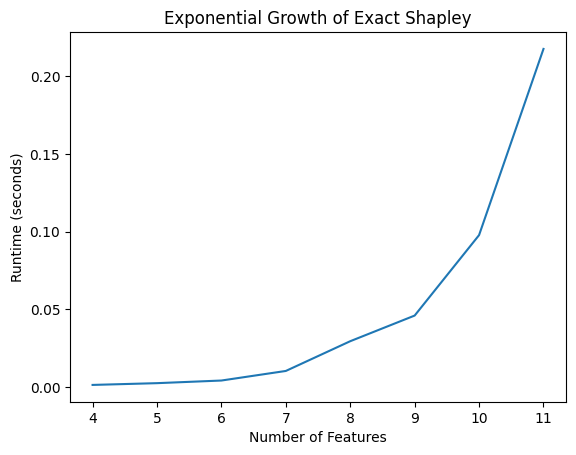

In [12]:
feature_counts = range(4, 12)
times = []

for n in feature_counts:
    x = np.random.rand(n)
    start = time.time()
    shapley_exact(model, x)
    end = time.time()

    times.append(end - start)
    print(f"Features: {n}, Time: {end - start:.4f} sec")

plt.plot(feature_counts, times)
plt.xlabel("Number of Features")
plt.ylabel("Runtime (seconds)")
plt.title("Exponential Growth of Exact Shapley")
plt.show()

## Approximate Shapley via Permutation Sampling

Instead of enumerating all subsets,  
we sample random feature orderings.

Complexity:
$O(M n)$

Where:
- M = number of permutations

In [13]:
def shapley_approx(model, x, num_samples=1000):
    n = len(x)
    shapley_values = np.zeros(n)

    for _ in range(num_samples):
        perm = np.random.permutation(n)
        x_subset = np.zeros(n)
        prev_val = model(x_subset)

        for idx in perm:
            x_subset[idx] = x[idx]
            new_val = model(x_subset)
            shapley_values[idx] += new_val - prev_val
            prev_val = new_val

    return shapley_values / num_samples

In [15]:
n = 15
x = np.random.rand(n)

start = time.time()
shapley_approx(model, x, num_samples=1000)
end = time.time()

print(f"Approximate SHAP (n=15) Time: {end - start:.4f} sec")

Approximate SHAP (n=15) Time: 0.1342 sec


## TreeSHAP (Polynomial Time)

TreeSHAP leverages tree structure.

Complexity:
$O(T L D^2)$

Where:
- T = number of trees
- L = leaves
- D = depth

Now we compare brute force vs TreeSHAP on a tree model.

In [16]:
X, y = make_regression(
    n_samples=1000,
    n_features=20,
    noise=0.1,
    random_state=42
)

model_tree = RandomForestRegressor(n_estimators=50)
model_tree.fit(X, y)

RandomForestRegressor(n_estimators=50)

In [17]:
explainer = shap.TreeExplainer(model_tree)

start = time.time()
shap_values = explainer.shap_values(X[:10])
end = time.time()

print(f"TreeSHAP Time (20 features): {end - start:.4f} sec")

TreeSHAP Time (20 features): 0.5666 sec


## Comparison Summary

| Method | Exact? | Complexity | Practical? |
|--------|--------|------------|------------|
| Brute Force | Yes | O(n 2^n) | No |
| Monte Carlo | Approx | O(M n) | Yes |
| TreeSHAP | Yes (trees) | Polynomial | Yes |

Key Insight:
- Exponential complexity comes from enumerating all coalitions.
- TreeSHAP avoids enumeration by dynamic programming along tree paths.

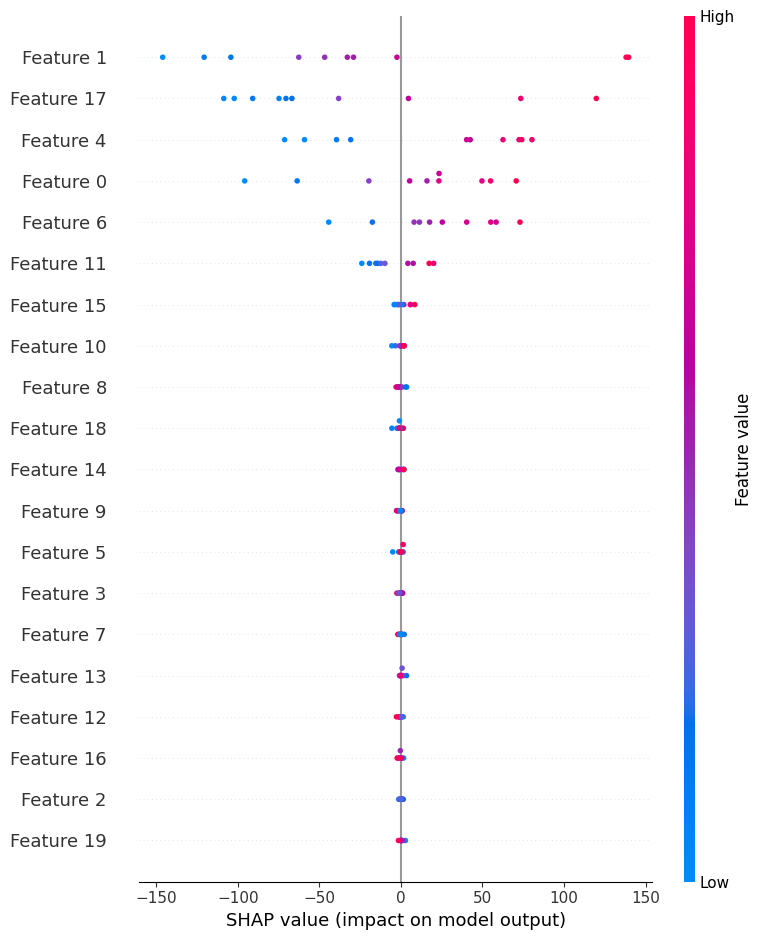

In [18]:
shap.summary_plot(shap_values, X[:10])